Loading: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
W shape: (35, 512)


/tmp/ipykernel_1062390/1082840751.py:270: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


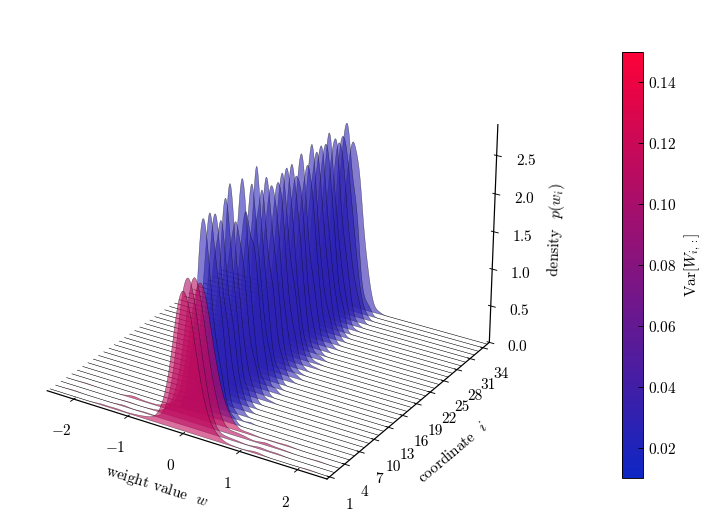

In [3]:
# === Styled 3D ridgeline for p(w_i) + WW^T heatmap (custom hex gradient, custom vmin/vmax, clean boxed look) ===
import os, sys, glob, math
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------
def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------
def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")

def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    # Hide the grey panes
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    # Also kill gridlines via _axinfo (mplot3d internals)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        # Emphasize axis (coordinate) lines
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    # Make the surrounding box lines a touch darker
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Loading helpers
# -----------------------------------------------------------------------------
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a

# -----------------------------------------------------------------------------
# Minimal 1D Gaussian KDE (no SciPy dependency)
# -----------------------------------------------------------------------------
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).reshape(-1)
    G = np.asarray(grid, dtype=np.float64).reshape(-1)
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if n == 1:
        bw = 1e-3 if bandwidth is None else float(bandwidth)
    else:
        if bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
        else:
            bw = float(bandwidth)
        bw = max(bw, 1e-12)
    z = (G[:, None] - x[None, :]) / bw
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * bw * math.sqrt(2.0 * math.pi))
    return dens

# -----------------------------------------------------------------------------
# Palette → colormap (customizable with hex stops)
# -----------------------------------------------------------------------------
def linear_cmap_from_hex(stops_hex=None, name="custommap"):
    """
    Build a linear segmented colormap from a list of hex color stops.
    - stops_hex: list like ['#0066ff', '#ff3366'] or with a middle ['#0066ff','#8a3ffc','#ff3366'].
    """
    if stops_hex is None:
        # Default to original palette idea (blue → purple → red) via slim_plotters
        stops_hex = [color("blue"), color("purple"), color("red")]
    return LinearSegmentedColormap.from_list(name, stops_hex, N=256)

# -----------------------------------------------------------------------------
# Styled WW^T heatmap (custom cmap + vmin/vmax + boxed look)
# -----------------------------------------------------------------------------


# -----------------------------------------------------------------------------
# Styled 3D ridgeline for p(w_i) (custom cmap stops + vmin/vmax for variance + boxed look)
# -----------------------------------------------------------------------------
def plot_coordinate_kdes_3d(
    W,
    grid_points=401,
    weight_range=None,
    bandwidth=None,
    normalize_rows=False,   # keep absolute heights to reflect variance
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,           # >1 to thin if d is large
    max_rows=None,
    cmap_stops_hex=None,    # list of hex colors for gradient (start/stop or start/mid/stop)
    var_vmin=None,          # min variance mapped to colormap (if None, computed)
    var_vmax=None           # max variance mapped to colormap (if None, computed)
):
    W_np = W.detach().cpu().numpy()
    d, N = W_np.shape

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # robust symmetric range if not provided
    if weight_range is None:
        abs_vals = np.abs(W_np).ravel()
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)

    grid = np.linspace(lo, hi, grid_points)

    dens, variances = [], []
    for i in rows:
        di = gaussian_kde_1d(W_np[i, :], grid, bandwidth=bandwidth)
        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m
        dens.append(di)
        variances.append(np.var(W_np[i, :], ddof=1))
    dens = np.asarray(dens)
    variances = np.asarray(variances)

    # color by variance using your custom palette
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use): vmin_use = vmin_auto
    if not np.isfinite(vmax_use): vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di, v in zip(dens, variances):
        poly = list(zip(grid, di)) + [(grid[-1], 0.0), (grid[0], 0.0)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )

    fig = plt.figure(figsize=(10.0, 6.0))
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')
    ys = np.arange(len(rows)) * y_step
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens)) if dens.size else 1.0
    ax.set_zlim(0.0, zmax * 1.05)

    # labels/ticks (styled by your rcParams)
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(r"density  $p(w_i)$")
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$")

    # Clean boxed style (no grey panes, no grid; keep coordinate lines)
    style_3d_axes_box(ax)

    #ax.set_title("3D stacked densities  $p(w_i)$  (color = row variance)")
    plt.tight_layout()
    plt.show()
    fig.savefig("/home/goring/mean_field_langevin/plots/plots/_pw.svg", bbox_inches="tight")

    return fig

# -----------------------------------------------------------------------------
# Usage
# -----------------------------------------------------------------------------
# Option A: direct .pt file (set to your path) OR leave None and use Option B
MODEL_FILE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"

# Option B: newest final_model_*.pt in this directory
MODEL_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"

if not MODEL_FILE:
    MODEL_FILE = find_latest_model(MODEL_DIR, prefix="final_model_", ext=".pt")

print("Loading:", MODEL_FILE)
W, a = load_WA_from_state_dict(MODEL_FILE)
print("W shape:", tuple(W.shape))

# ---- Customize your colors & ranges here ----
# Example: start/stop hex for both plots (you can add a middle color if you like)
CMAP_STOPS = ["#0E26C4","#FD0139"]       # or e.g. ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap value range (colorbar); set to None to auto scale
HEAT_VMIN = 0.12
HEAT_VMAX = 0.02

# Ridgeline variance → color mapping; set to None to auto scale
VAR_VMIN = 0.01
VAR_VMAX = 0.15

# 1) WW^T heatmap

# 2) 3D ridgeline for p(w_i)
_ = plot_coordinate_kdes_3d(
    W,
    grid_points=1000,
    weight_range=(-2.5, 2.5),     # or set a fixed range like (-0.6, 0.6)
    bandwidth=None,           # Scott's rule per row
    normalize_rows=False,     # keep absolute heights to reflect variance
    y_step=0.85,
    alpha=0.59,
    elev=26,
    azim=-58,
    row_stride=1,             # use 2/3/... to thin if d is large
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX
)


In [2]:
# === Multi-model average p(w_i) ridgeline + average WW^T heatmap ===
# Add this below your existing imports/helpers (keeps your theme + helpers)

# -------------------------------------------------------------------
# Utilities to load many models and sanity-check shapes
# -------------------------------------------------------------------

# === Styled 3D ridgeline for p(w_i) + WW^T heatmap (custom hex gradient, custom vmin/vmax, clean boxed look) ===
import os, sys, glob, math
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator  # << for pretty log ticks

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------
def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plots_utils/",
        "plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------
def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")

def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    # Hide the grey panes
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    # Also kill gridlines via _axinfo (mplot3d internals)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        # Emphasize axis (coordinate) lines
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    # Make the surrounding box lines a touch darker
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Loading helpers
# -----------------------------------------------------------------------------
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a


def load_many_W(model_paths, map_location="cpu"):
    """Return list of W tensors (each d x N_i). All must share same d."""
    W_list = []
    d_ref = None
    for p in model_paths:
        W, a = load_WA_from_state_dict(p, map_location=map_location)
        if W.ndim != 2:
            raise ValueError(f"{p}: expected W to be 2D, got {tuple(W.shape)}")
        if d_ref is None:
            d_ref = W.shape[0]
        elif W.shape[0] != d_ref:
            raise ValueError(
                f"All models must share the same number of rows d. "
                f"Got {d_ref} and {W.shape[0]} for {p}."
            )
        W_list.append(W.detach().cpu())
    return W_list  # [d x N_i], same d, variable N_i okay

# -------------------------------------------------------------------
# Average WW^T heatmap across models (clean, boxed, custom cmap+range)
# -------------------------------------------------------------------
def plot_avg_WWT_heatmap(
    W_list,
    cmap_stops_hex=None,
    vmin=None,
    vmax=None,
    title=r"Average $WW^\top$",
    annotate=False,
    savepath="plots/_WWT_avg.svg",
):
    # Average Gram matrices
    Gs = []
    for W in W_list:
        Wnp = W.numpy()
        Gs.append(Wnp @ Wnp.T)
    G = np.mean(Gs, axis=0)

    # custom cmap + robust vmin/vmax
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="heatmap")
    vmin_auto, vmax_auto = float(np.min(G)), float(np.max(G))
    vmin_use = vmin_auto if vmin is None else float(vmin)
    vmax_use = vmax_auto if vmax is None else float(vmax)
    if not np.isfinite(vmin_use): vmin_use = vmin_auto
    if not np.isfinite(vmax_use): vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12  # prevent mpl error if inverted

    fig, ax = plt.subplots(figsize=(7.2, 6.4))
    im = ax.imshow(G, cmap=cmap, vmin=vmin_use, vmax=vmax_use, origin="upper")
    ax.set_title(title)
    ax.set_xlabel("coordinate  $j$")
    ax.set_ylabel("coordinate  $i$")
    style_axes_box(ax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"value")

    if annotate and G.shape[0] <= 40:
        for i in range(G.shape[0]):
            for j in range(G.shape[1]):
                ax.text(j, i, f"{G[i, j]:.2f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Multi-model ridgeline: average KDE per coordinate
#   avg_mode = 'mixture'  -> average per-model KDEs (true mean of dists)
#            = 'pool'     -> one KDE on concatenated samples across models
# variance_mode = 'pooled' (default), 'mean', or 'median' for colorbar
# -------------------------------------------------------------------
def plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=401,
    weight_range=None,
    bandwidth=None,          # if given, used for *all* KDEs
    normalize_rows=False,    # keep False to reflect absolute scale
    avg_mode="mixture",      # 'mixture' or 'pool'
    variance_mode="pooled",  # 'pooled'|'mean'|'median'
    model_weights=None,      # optional weights per model (mixture only)
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=None,
    var_vmin=None,
    var_vmax=None,
    z_log=True,
    z_floor=1e-6,
    savepath="plots/_pw_avg.svg",
):
    # ---------- grid range ----------
    d = W_list[0].shape[0]
    if weight_range is None:
        abs_vals = np.concatenate([np.abs(W.numpy()).ravel() for W in W_list])
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # ---------- per-row densities + variance stats across models ----------
    dens_rows = []
    var_rows = []

    # weights for mixture averaging
    if avg_mode == "mixture":
        if model_weights is None:
            # default: proportional to per-model sample count for that row
            model_weights = np.array([W.shape[1] for W in W_list], dtype=float)
        mw = model_weights / np.sum(model_weights)
    else:
        mw = None

    for i in rows:
        # Collect samples for row i
        samples_list = [W[i, :].numpy() for W in W_list]
        Ns = [s.size for s in samples_list if s.size > 0]

        # ---- variance across models (colorbar stat) ----
        if variance_mode == "pooled":
            # variance on concatenated samples (unbiased, ddof=1)
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            v_stat = float(np.var(pooled, ddof=1)) if pooled.size > 1 else 0.0
        else:
            # per-model row variance, then mean/median
            per_model_vars = [float(np.var(s, ddof=1)) if s.size > 1 else 0.0 for s in samples_list]
            if variance_mode == "mean":
                v_stat = float(np.mean(per_model_vars)) if per_model_vars else 0.0
            elif variance_mode == "median":
                v_stat = float(np.median(per_model_vars)) if per_model_vars else 0.0
            else:
                raise ValueError("variance_mode must be 'pooled', 'mean', or 'median'")
        var_rows.append(v_stat)

        # ---- density per row (mixture average or pooled) ----
        if avg_mode == "pool":
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            di = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        elif avg_mode == "mixture":
            # average the per-model KDEs with weights mw (default ∝ sample size)
            parts = []
            for m, s in enumerate(samples_list):
                di_m = gaussian_kde_1d(s, grid, bandwidth=bandwidth)
                parts.append(mw[m] * di_m)
            di = np.sum(parts, axis=0) if parts else np.zeros_like(grid)
        else:
            raise ValueError("avg_mode must be 'mixture' or 'pool'")

        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m

        dens_rows.append(di)

    dens = np.asarray(dens_rows)         # shape: (#rows) x grid_points
    variances = np.asarray(var_rows)     # shape: (#rows,)

    # ---------- log transform BEFORE polygons ----------
    if z_log:
        dens = np.maximum(dens, z_floor)
        dens_plot = np.log10(dens)
        base_z = math.log10(z_floor)
        zlabel = r"log density  $p(w_i)$"
    else:
        dens_plot = dens
        base_z = 0.0
        zlabel = r"density  $p(w_i)$"

    # ---------- color by variance ----------
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap_multi")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use): vmin_use = vmin_auto
    if not np.isfinite(vmax_use): vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di_plot, v in zip(dens_plot, variances):
        poly = list(zip(grid, di_plot)) + [(grid[-1], base_z), (grid[0], base_z)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )

    fig = plt.figure(figsize=(10.5, 6.2))
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')
    ys = np.arange(len(rows)) * y_step
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens_plot)) if dens_plot.size else 1.0
    ax.set_zlim(base_z, zmax * 1.05)

    # pretty ticks if log plotting
    if z_log:
        ax.zaxis.set_major_locator(MaxNLocator(integer=True))
        ax.zaxis.set_major_formatter(FuncFormatter(lambda v, p: rf"$10^{{{int(v)}}}$"))

    # labels/ticks
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(zlabel)
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$ (" + variance_mode + ")")

    # clean boxed look
    style_3d_axes_box(ax)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------
# Provide an explicit list of model files you want to average over:
MODEL_FILES = ["/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    # put your paths here (absolute or relative)
    # e.g. "results/.../final_model_*.pt"
]
if not MODEL_FILES:
    # fallback: grab 10 newest final_model_*.pt from a directory (edit as needed)
    MODEL_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"
    all_candidates = sorted(
        glob.glob(os.path.join(MODEL_DIR, "final_model_*.pt")),
        key=os.path.getmtime
    )
    MODEL_FILES = all_candidates[-10:]  # last 10

print("Loading N models:", len(MODEL_FILES))
W_list = load_many_W(MODEL_FILES, map_location="cpu")

# ---- Customize colors/ranges as before ----
CMAP_STOPS = ["#0E26C4", "#FD0139"]     # or ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap color range (optional). If you had vmin>vmax, we guard against it.
HEAT_VMIN = 0.02
HEAT_VMAX = 0.12

# Variance → color mapping for ridgeline (pooled across models by default)
VAR_VMIN = 0.01
VAR_VMAX = 0.10

# 1) Average WW^T heatmap across models
_ = plot_avg_WWT_heatmap(
    W_list,
    cmap_stops_hex=CMAP_STOPS,
    vmin=HEAT_VMIN,
    vmax=HEAT_VMAX,
    title=r"Average $WW^\top$ across models",
    annotate=False,
    savepath="plots/_WWT_avg.svg",
)

# 2) Multi-model ridgeline: average p(w_i) across models
_ = plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=1000,
    weight_range=(-2.5, 2.5),
    bandwidth=None,               # per-KDE Scott's rule (unless you set a fixed bw)
    normalize_rows=False,
    avg_mode="mixture",           # 'mixture' (mean of per-model densities) or 'pool'
    variance_mode="pooled",       # 'pooled'|'mean'|'median'
    model_weights=None,           # or e.g. weights ∝ N_i
    y_step=0.85,
    alpha=0.59,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX,
    z_log=True,
    z_floor=1e-3,
    savepath="plots/_pw_avg.svg",
)


Loading N models: 3


NameError: name 'linear_cmap_from_hex' is not defined

Loading A: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_100_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt
Loading B: /home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt


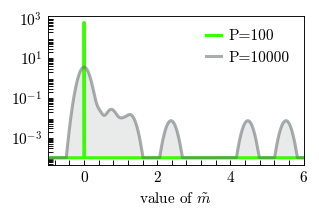

In [12]:
# === WW^T heatmap + unconditional p(m~ = a * J_S(w)) with slim-style controls (TWO MODELS overlay) ===
import os, sys, glob, math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ----------------------------------------------------------------------------- #
# robust import of your slim_plotters.py
# ----------------------------------------------------------------------------- #
def import_slim_plotters():
    candidates = [
        "/home/goring/mean_field_langevin/plot_utils",
        "/home/goring/mean_field_langevin/plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            import slim_plotters as sp
            return sp
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass
    raise ModuleNotFoundError("slim_plotters.py not found — update candidate paths above.")

sp = import_slim_plotters()
apply, color, COLORS = sp.apply, sp.color, sp.COLORS
apply(theme="light", serif=True)  # or theme="dark"

# ----------------------------------------------------------------------------- #
# IO helpers
# ----------------------------------------------------------------------------- #
def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]

def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach()
        a = sd['a'].detach()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach()
        a = st['a'].detach()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach()
        a = sd[key_a].detach()
    if a.ndim > 1:
        a = a.view(-1)
    return W.float().cpu(), a.float().cpu()

# ----------------------------------------------------------------------------- #
# Monte Carlo estimator for J_S(w) (S = {0,1,2,3} by default)
# ----------------------------------------------------------------------------- #
@torch.no_grad()
def estimate_JS_for_all_neurons(W, S=(0,1,2,3), num_samples=200_000, batch_size=100_000,
                                device=None, seed=123):
    d, N = W.shape
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    gen = torch.Generator(device=device).manual_seed(seed)
    Wd = W.to(device, non_blocking=True)
    accum = torch.zeros(N, device=device, dtype=torch.float32)
    total = 0
    B, P = batch_size, num_samples
    iters = (P + B - 1) // B

    for it in range(iters):
        b = B if (it+1)*B <= P else (P - it*B)
        X = (torch.randint(0, 2, (b, d), generator=gen, device=device, dtype=torch.int8).float() * 2.0) - 1.0
        chi = X[:, list(S)].prod(dim=1, keepdim=True)   # (b,1)
        Z = F.relu(X @ Wd)                              # (b,N)
        accum += (Z * chi).sum(dim=0)
        total += b

    return (accum / float(total)).to('cpu')  # (N,)

# ----------------------------------------------------------------------------- #
# Simple Gaussian KDE (no SciPy)
# ----------------------------------------------------------------------------- #
def gaussian_kde_1d(samples, grid, bandwidth=None):
    x = np.asarray(samples, dtype=np.float64).ravel()
    G = np.asarray(grid, dtype=np.float64).ravel()
    n = x.size
    if n == 0:
        return np.zeros_like(G)
    if bandwidth is None:
        std = np.std(x, ddof=1)
        bandwidth = 1.06 * std * n ** (-1/5) if std > 0 else 1e-3
    h = max(float(bandwidth), 1e-12)
    z = (G[:, None] - x[None, :]) / h
    dens = np.exp(-0.5 * z * z).sum(axis=1) / (n * h * math.sqrt(2.0 * math.pi))
    return dens



# ----------------------------------------------------------------------------- #
# Plot 2 (SINGLE model): unchanged styled version
# ----------------------------------------------------------------------------- #
# Drop-in replacement: two-model overlay WITH MINOR TICKS on x (linear) and y (log)
# Drop-in replacement: two-model overlay with minor ticks ONLY bottom/left
def plot_mtilde_distribution_two_models(
    a1, JS1, a2, JS2, *,
    grid_points=801,
    weight_range=None,         # (lo, hi) or None (auto from both)
    color_hex1="#8710FF",      # color for model 1
    color_hex2="#01B5EB",      # color for model 2
    alpha1=1.0, alpha2=0.55,   # opacity only
    linewidth=2.0,
    fill_alpha_scale=0.25,     # fill alpha = alpha*fill_alpha_scale
    density_floor=1e-12,
    label1="run 1", label2="run 2",
    width=4.6, aspect=1.35,
    x_range=None, y_range=None
):
    import numpy as np
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    m1 = a1.detach().cpu().numpy().ravel() * JS1.detach().cpu().numpy().ravel()
    m2 = a2.detach().cpu().numpy().ravel() * JS2.detach().cpu().numpy().ravel()

    if weight_range is None:
        all_abs = np.abs(np.concatenate([m1, m2]))
        hi = float(np.quantile(all_abs, 0.995)) if all_abs.size else 1.0
        if not np.isfinite(hi) or hi <= 0: hi = max(1.0, float(all_abs.max()))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    p1 = np.clip(gaussian_kde_1d(m1, grid), density_floor, None)
    p2 = np.clip(gaussian_kde_1d(m2, grid), density_floor, None)

    fig, ax = plt.subplots(figsize=(width, width / aspect))
    # curves + fill
    ax.semilogy(grid, p1, color=color_hex1, lw=linewidth, alpha=alpha1, label=label1)
    ax.fill_between(grid, p1, density_floor, color=color_hex1, alpha=alpha1*fill_alpha_scale, linewidth=0)

    ax.semilogy(grid, p2, color=color_hex2, lw=linewidth, alpha=alpha2, label=label2)
    ax.fill_between(grid, p2, density_floor, color=color_hex2, alpha=alpha2*fill_alpha_scale, linewidth=0)

    # labels & legend
    ax.set_title("")
    ax.set_xlabel(r"value of $\tilde m$")
    ax.set_ylabel("")
    ax.legend(frameon=False, loc="upper right")

    # ---- MINOR TICKS: only bottom & left ----
    # linear x minors
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    # log y minors (2..9)
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())

    # ticks bottom/left only (no top/right)
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)  # shorter minor ticks

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()
    fig.savefig("/home/goring/mean_field_langevin/plots/plots/m.svg", bbox_inches="tight")

    return fig




# ----------------------------------------------------------------------------- #
# === Usage ===
# ----------------------------------------------------------------------------- #
MODEL_A = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_100_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
MODEL_B = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"

print("Loading A:", MODEL_A)
WA, aA = load_WA_from_state_dict(MODEL_A)
print("Loading B:", MODEL_B)
WB, aB = load_WA_from_state_dict(MODEL_B)

# optional: heatmap for one model

JS_A = estimate_JS_for_all_neurons(WA, S=(0,1,2,3), num_samples=500_000, batch_size=100_000,
                                   device="cuda" if torch.cuda.is_available() else "cpu", seed=123)
JS_B = estimate_JS_for_all_neurons(WB, S=(0,1,2,3), num_samples=200_000, batch_size=100_000,
                                   device="cuda" if torch.cuda.is_available() else "cpu", seed=124)
_ = plot_mtilde_distribution_two_models(
    aA, JS_A, aB, JS_B,
    grid_points=18001,
    weight_range=(-15.5, 15.5),   # or None
    color_hex1="#39FD01",         # purple for run 1
    color_hex2="#636A6B",          # blue for run 2
    alpha1=1.0, alpha2=0.55, 
    linewidth=2.0,
    fill_alpha_scale=0.25,
    density_floor=1e-4,
    label1="P=100", label2="P=10000",
    width=3, aspect=1.45,
    x_range=(-1, 6),             # or None
    y_range=None
)



[init] loading & sampling from 3 models...
[final] loading & sampling from 3 models...


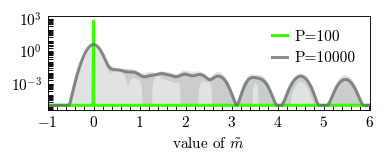

In [20]:
# ----------------------------------------------------------------------------- #
# Multi-model helpers for m~ = a * J_S(w)   (init vs final groups)
# ----------------------------------------------------------------------------- #
def load_many_WA(model_paths, map_location="cpu"):
    Ws, As = [], []
    d_ref = None
    for p in model_paths:
        W, a = load_WA_from_state_dict(p, map_location=map_location)
        if d_ref is None:
            d_ref = W.shape[0]
        elif W.shape[0] != d_ref:
            raise ValueError(f"Incompatible d across models: {d_ref} vs {W.shape[0]} for {p}")
        Ws.append(W)
        As.append(a)
    return Ws, As  # lists of tensors

@torch.no_grad()
def mtilde_list_from_models(model_paths, S=(0,1,2,3), *,
                            num_samples=200_000, batch_size=100_000,
                            device=None, seed=123, seed_step=7):
    """Return list of numpy arrays of \tilde m for each model."""
    Ws, As = load_many_WA(model_paths, map_location="cpu")
    mts = []
    for k, (W, a) in enumerate(zip(Ws, As)):
        JS = estimate_JS_for_all_neurons(
            W, S=S, num_samples=num_samples, batch_size=batch_size,
            device=device, seed=seed + k*seed_step
        )
        mtilde = (a.view(-1).cpu().numpy()) * (JS.view(-1).cpu().numpy())
        mts.append(mtilde)
    return mts  # list of 1D numpy arrays

# --------------------------- KDE aggregators --------------------------------- #
def _weighted_mean_std(arr_stack, weights=None):
    """arr_stack: shape (M, G). weights: (M,) or None (equal)."""
    arr = np.asarray(arr_stack, float)
    M, G = arr.shape
    if M == 0:
        return np.zeros(G), np.zeros(G)
    if weights is None:
        w = np.ones(M, dtype=float)
    else:
        w = np.asarray(weights, float)
        if w.ndim != 1 or w.size != M: raise ValueError("weights must match #models")
    wsum = np.sum(w)
    if wsum <= 0: w = np.ones(M, float); wsum = float(M)
    w = w / wsum
    mean = (w[:, None] * arr).sum(axis=0)
    var = (w[:, None] * (arr - mean)**2).sum(axis=0)  # population-style
    std = np.sqrt(np.maximum(var, 0.0))
    return mean, std

def kde_aggregate(m_list, grid, *, mode="mixture", bandwidth=None,
                  weights="auto", density_floor=1e-12, return_all=False):
    """
    mode='mixture': average per-model KDEs (mean-of-distributions). Provides mean & std.
    mode='pool'   : one KDE on concatenated samples (no across-run std).
    weights='auto' -> weights ∝ len(m) for each model (mixture only).
    """
    if mode not in ("mixture", "pool"):
        raise ValueError("mode must be 'mixture' or 'pool'")
    if mode == "pool":
        pooled = np.concatenate(m_list) if len(m_list) else np.array([])
        d = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        d = np.clip(d, density_floor, None)
        return (d, None) if not return_all else (d, None, None)
    # mixture: per-model densities, then weighted mean/std
    per = []
    for m in m_list:
        di = gaussian_kde_1d(m, grid, bandwidth=bandwidth)
        per.append(np.clip(di, density_floor, None))
    per = np.asarray(per)
    if weights == "auto":
        w = np.array([len(m) for m in m_list], dtype=float)
    else:
        w = np.asarray(weights) if weights is not None else None
    mean, std = _weighted_mean_std(per, w)
    return (mean, std) if not return_all else (mean, std, per)

# --------------------------- Plot: two groups -------------------------------- #
def plot_mtilde_two_groups_multi_models(
    init_model_paths, final_model_paths, *,
    S=(0,1,2,3),
    # Monte Carlo
    num_samples_init=300_000, num_samples_final=300_000,
    batch_size=100_000, device=None, seed_init=123, seed_final=456,
    # KDE & aggregation
    avg_mode="mixture",            # 'mixture' (mean of dists) | 'pool' (concatenate)
    bandwidth=None,                # fixed bw; None -> Scott per-KDE
    show_band=True, band_k=1.0,    # fill +/- k*std in 'mixture' mode
    # Styling
    grid_points=2001, weight_range=None,
    color_init="#39FD01", color_final="#636A6B",
    alpha_init=1.0, alpha_final=0.75,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-6,
    label_init="init", label_final="final",
    width=4.6, aspect=1.35,
    x_range=None, y_range=None,
    savepath="plots/m_groups.svg"
):
    from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter

    # --- compute all \tilde m samples ---
    print(f"[init] loading & sampling from {len(init_model_paths)} models...")
    m_init = mtilde_list_from_models(
        init_model_paths, S=S,
        num_samples=num_samples_init, batch_size=batch_size,
        device=device, seed=seed_init
    )
    print(f"[final] loading & sampling from {len(final_model_paths)} models...")
    m_final = mtilde_list_from_models(
        final_model_paths, S=S,
        num_samples=num_samples_final, batch_size=batch_size,
        device=device, seed=seed_final
    )

    # --- grid range ---
    if weight_range is None:
        all_abs = np.abs(np.concatenate([np.concatenate(m_init), np.concatenate(m_final)])) \
                  if (m_init and m_final) else np.array([1.0])
        hi = float(np.quantile(all_abs, 0.995))
        if not np.isfinite(hi) or hi <= 0:
            hi = max(1.0, float(all_abs.max()))
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    # --- aggregate KDEs for both groups ---
    dI, sI = kde_aggregate(m_init, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)
    dF, sF = kde_aggregate(m_final, grid, mode=avg_mode, bandwidth=bandwidth,
                           weights="auto", density_floor=density_floor)

    # --- plot ---
    fig, ax = plt.subplots(figsize=(width, width / aspect))

    # INIT
    ax.semilogy(grid, dI, color=color_init, lw=linewidth, alpha=alpha_init, label=label_init)
    ax.fill_between(grid, dI, density_floor, color=color_init,
                    alpha=alpha_init*fill_alpha_scale, linewidth=0)
    if show_band and sI is not None and np.any(sI > 0):
        loI = np.clip(dI - band_k*sI, density_floor, None)
        hiI = np.clip(dI + band_k*sI, density_floor, None)
        ax.fill_between(grid, loI, hiI, color=color_init, alpha=0.18, linewidth=0)

    # FINAL
    ax.semilogy(grid, dF, color=color_final, lw=linewidth, alpha=alpha_final, label=label_final)
    ax.fill_between(grid, dF, density_floor, color=color_final,
                    alpha=alpha_final*fill_alpha_scale, linewidth=0)
    if show_band and sF is not None and np.any(sF > 0):
        loF = np.clip(dF - band_k*sF, density_floor, None)
        hiF = np.clip(dF + band_k*sF, density_floor, None)
        ax.fill_between(grid, loF, hiF, color=color_final, alpha=0.18, linewidth=0)

    # Labels/legend
    ax.set_xlabel(r"value of $\tilde m$")
    ax.legend(frameon=False, loc="upper right")

    # Minor ticks: bottom & left only
    ax.xaxis.set_minor_locator(AutoMinorLocator(5))
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2,10)*0.1, numticks=100))
    ax.yaxis.set_minor_formatter(NullFormatter())
    ax.tick_params(axis='x', which='both', direction='in', bottom=True, top=False)
    ax.tick_params(axis='y', which='both', direction='in', left=True,  right=False)
    ax.tick_params(which='minor', length=3.0)

    if x_range is not None: ax.set_xlim(x_range)
    if y_range is not None: ax.set_ylim(y_range)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig



# --- Provide your model lists ---
INIT_MODELS = [
  "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_100_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_100_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_100_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
]
FINAL_MODELS = [
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
               "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
]

# Fallback examples (edit directories as needed)
if not INIT_MODELS or not FINAL_MODELS:
    BASE = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"
    # just examples of picking 5 oldest as "init" and 5 newest as "final"
    all_pts = sorted(glob.glob(os.path.join(BASE, "final_model_*.pt")), key=os.path.getmtime)
    INIT_MODELS = all_pts[:5]
    FINAL_MODELS = all_pts[-5:]

_ = plot_mtilde_two_groups_multi_models(
    INIT_MODELS, FINAL_MODELS,
    S=(0,1,2,3),
    num_samples_init=300_000, num_samples_final=300_000,
    batch_size=100_000,
    device="cuda" if torch.cuda.is_available() else "cpu",
    seed_init=123, seed_final=456,
    avg_mode="mixture",         # <- true mean of per-model densities
    bandwidth=None,             # <- use Scott per model; set float to fix bw
    show_band=True, band_k=1.0, # <- ±1σ band across runs (mixture mode)
    grid_points=6001, weight_range=(-10,10),
    color_init="#39FD01", color_final="#636A6B",
    alpha_init=1.0, alpha_final=0.75,
    linewidth=2.0, fill_alpha_scale=0.25,
    density_floor=1e-5,
    label_init="P=100", label_final="P=10000",
    width=3.6, aspect=2.3,
    x_range=(-1,6), y_range=None,
    savepath="plots/m_NN.svg"
)


In [ ]:
# === Multi-model average p(w_i) ridgeline + average WW^T heatmap ===
# Add this below your existing imports/helpers (keeps your theme + helpers)

# -------------------------------------------------------------------
# Utilities to load many models and sanity-check shapes
# -------------------------------------------------------------------

# === Styled 3D ridgeline for p(w_i) + WW^T heatmap (custom hex gradient, custom vmin/vmax, clean boxed look)
import os, sys, glob, math
import numpy as np
import torch
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import PolyCollection
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FuncFormatter, MaxNLocator  # << for pretty log ticks

# -----------------------------------------------------------------------------
# Locate & import slim_plotters.py no matter if it's in plot_utils/ or plots_utils/
# -----------------------------------------------------------------------------

def import_slim_plotters():
    # Common places to try — add your custom absolute path(s) here if needed
    candidates = [
        "/home/goring/mean_field_langevin/plots_utils/",
        "plots_utils",
        os.path.join(os.getcwd(), "plot_utils"),
        os.path.join(os.getcwd(), "plots_utils"),
    ]

    # 1) Try direct module path by adding the directory containing slim_plotters.py
    for d in candidates:
        if os.path.isfile(os.path.join(d, "slim_plotters.py")):
            if d not in sys.path:
                sys.path.insert(0, d)
            try:
                import slim_plotters as sp  # noqa
                return sp
            except Exception as e:
                print(f"[note] Found in {d} but import failed: {e!r}")

    # 2) Try package-style imports (requires __init__.py in the folder)
    for pkg in ("plot_utils.slim_plotters", "plots_utils.slim_plotters"):
        try:
            sp = __import__(pkg, fromlist=["*"])
            return sp
        except Exception:
            pass

    raise ModuleNotFoundError(
        "Could not import slim_plotters. "
        "Make sure slim_plotters.py exists in one of: "
        + ", ".join(candidates)
        + " (or update the 'candidates' list above)."
    )

sp = import_slim_plotters()
apply, color, COLORS, CYCLE = sp.apply, sp.color, sp.COLORS, sp.CYCLE

# Apply your theme (switch to theme='dark' if you like)
apply(theme="light", serif=True)

# -----------------------------------------------------------------------------
# Small helpers for a clean, boxed look (no grey panes, no grids)
# -----------------------------------------------------------------------------

def style_axes_box(ax):
    """2D axes: white background, no grid, visible spines."""
    ax.set_facecolor("white")
    ax.grid(False)
    for side in ("top", "right", "bottom", "left"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)
        ax.spines[side].set_color("black")
    ax.tick_params(axis="both", which="both", length=3, width=0.8, colors="black")


def style_3d_axes_box(ax):
    """3D axes: remove pane fills & grid; keep coordinate lines and box."""
    ax.set_facecolor("white")
    ax.grid(False)
    # Hide the grey panes
    try:
        ax.xaxis.pane.set_visible(False)
        ax.yaxis.pane.set_visible(False)
        ax.zaxis.pane.set_visible(False)
    except Exception:
        pass
    # Also kill gridlines via _axinfo (mplot3d internals)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        try:
            axis._axinfo["grid"]["linewidth"] = 0.0
            axis._axinfo["grid"]["color"] = (1, 1, 1, 0)
        except Exception:
            pass
        # Emphasize axis (coordinate) lines
        try:
            axis.line.set_color("black")
            axis.line.set_linewidth(0.8)
        except Exception:
            pass
    # Make the surrounding box lines a touch darker
    try:
        ax.w_xaxis.set_pane_color((1, 1, 1, 0))
        ax.w_yaxis.set_pane_color((1, 1, 1, 0))
        ax.w_zaxis.set_pane_color((1, 1, 1, 0))
    except Exception:
        pass

# -----------------------------------------------------------------------------
# Loading helpers
# -----------------------------------------------------------------------------

def find_latest_model(model_dir, prefix="final_model_", ext=".pt"):
    files = glob.glob(os.path.join(model_dir, f"{prefix}*{ext}"))
    if not files:
        raise FileNotFoundError(f"No {prefix}*{ext} files found in: {model_dir}")
    files.sort(key=os.path.getmtime)
    return files[-1]


def load_WA_from_state_dict(path, map_location="cpu"):
    sd = torch.load(path, map_location=map_location)
    if isinstance(sd, dict) and 'w' in sd and 'a' in sd:
        W = sd['w'].detach().cpu()
        a = sd['a'].detach().cpu()
    elif isinstance(sd, dict) and 'state_dict' in sd:
        st = sd['state_dict']
        W = st['w'].detach().cpu()
        a = st['a'].detach().cpu()
    else:
        keys = list(sd.keys())
        key_w = next(k for k in keys if k.endswith('w') and sd[k].ndim == 2)
        key_a = next(k for k in keys if k.endswith('a') and sd[k].ndim >= 1)
        W = sd[key_w].detach().cpu()
        a = sd[key_a].detach().cpu()
    return W, a


def load_many_W(model_paths, map_location="cpu"):
    """Return list of W tensors (each d x N_i). All must share same d."""
    W_list = []
    d_ref = None
    for p in model_paths:
        W, a = load_WA_from_state_dict(p, map_location=map_location)
        if W.ndim != 2:
            raise ValueError(f"{p}: expected W to be 2D, got {tuple(W.shape)}")
        if d_ref is None:
            d_ref = W.shape[0]
        elif W.shape[0] != d_ref:
            raise ValueError(
                f"All models must share the same number of rows d. "
                f"Got {d_ref} and {W.shape[0]} for {p}."
            )
        W_list.append(W.detach().cpu())
    return W_list  # [d x N_i], same d, variable N_i okay

# -------------------------------------------------------------------
# Average WW^T heatmap across models (clean, boxed, custom cmap+range)
# -------------------------------------------------------------------

def plot_avg_WWT_heatmap(
    W_list,
    cmap_stops_hex=None,
    vmin=None,
    vmax=None,
    title=r"Average $WW^	op$",
    annotate=False,
    savepath="plots/_WWT_avg.svg",
    figsize=(7.2, 6.4),
):
    """Average Gram (WW^T) across models and draw a boxed heatmap.

    New: pass `figsize=(width, height)` to control figure size.
    """
    # Average Gram matrices
    Gs = []
    for W in W_list:
        Wnp = W.numpy()
        Gs.append(Wnp @ Wnp.T)
    G = np.mean(Gs, axis=0)

    # custom cmap + robust vmin/vmax
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="heatmap")
    vmin_auto, vmax_auto = float(np.min(G)), float(np.max(G))
    vmin_use = vmin_auto if vmin is None else float(vmin)
    vmax_use = vmax_auto if vmax is None else float(vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12  # prevent mpl error if inverted

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(G, cmap=cmap, vmin=vmin_use, vmax=vmax_use, origin="upper")
    ax.set_title(title)
    ax.set_xlabel("coordinate  $j$")
    ax.set_ylabel("coordinate  $i$")
    style_axes_box(ax)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r"value")

    if annotate and G.shape[0] <= 40:
        for i in range(G.shape[0]):
            for j in range(G.shape[1]):
                ax.text(j, i, f"{G[i, j]:.2f}", ha="center", va="center", fontsize=7)

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Multi-model ridgeline: average KDE per coordinate
#   avg_mode = 'mixture'  -> average per-model KDEs (true mean of dists)
#            = 'pool'     -> one KDE on concatenated samples across models
# variance_mode = 'pooled' (default), 'mean', or 'median' for colorbar
# -------------------------------------------------------------------

def plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=401,
    weight_range=None,
    bandwidth=None,          # if given, used for *all* KDEs
    normalize_rows=False,    # keep False to reflect absolute scale
    avg_mode="mixture",      # 'mixture' or 'pool'
    variance_mode="pooled",  # 'pooled'|'mean'|'median'
    model_weights=None,      # optional weights per model (mixture only)
    y_step=0.85,
    alpha=0.85,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=None,
    var_vmin=None,
    var_vmax=None,
    z_log=True,
    z_floor=1e-6,
    savepath="plots/_pw_avg.svg",
    # New knobs for making it FLATTER
    figsize=(10.5, 6.2),     # figure size (w, h)
    z_scale=1.0,             # compress vertical scale: e.g. 0.3 for much flatter
    box_aspect=None,         # e.g. (1, 1, 0.25) to squash z vs x/y
    ortho=True,              # use orthographic projection to reduce perspective
    # New: explicit log tick exponents (unscaled). Example: (0,3) -> show 10^0 and 10^3
    z_log_ticks=None,
):
    """3D ridgeline of average per-row densities across models.

    To make the plot flatter:
      - Lower `z_scale` (try 0.2–0.5).
      - Pass a smaller height in `figsize` (e.g., (10.5, 3.6)).
      - Set `box_aspect=(1, 1, 0.25)` (requires Matplotlib ≥3.3).
      - Reduce `y_step` to squeeze rows closer together.
      - Keep `ortho=True` to reduce perspective exaggeration.

    Ticks:
      - If `z_log=True` and `z_log_ticks` is provided (e.g., `(0, 3)`), the Z axis
        will only show those powers of 10.
    """
    # ---------- grid range ----------
    d = W_list[0].shape[0]
    if weight_range is None:
        abs_vals = np.concatenate([np.abs(W.numpy()).ravel() for W in W_list])
        if abs_vals.size:
            q = np.quantile(abs_vals, 0.995)
            hi = float(q if np.isfinite(q) and q > 0 else (abs_vals.max() if abs_vals.max() > 0 else 1.0))
        else:
            hi = 1.0
        lo = -hi
    else:
        lo, hi = map(float, weight_range)
    grid = np.linspace(lo, hi, grid_points)

    rows = np.arange(0, d, row_stride)
    if max_rows is not None:
        rows = rows[:max_rows]

    # ---------- per-row densities + variance stats across models ----------
    dens_rows = []
    var_rows = []

    # weights for mixture averaging
    if avg_mode == "mixture":
        if model_weights is None:
            # default: proportional to per-model sample count for that row
            model_weights = np.array([W.shape[1] for W in W_list], dtype=float)
        mw = model_weights / np.sum(model_weights)
    else:
        mw = None

    for i in rows:
        # Collect samples for row i
        samples_list = [W[i, :].numpy() for W in W_list]
        Ns = [s.size for s in samples_list if s.size > 0]

        # ---- variance across models (colorbar stat) ----
        if variance_mode == "pooled":
            # variance on concatenated samples (unbiased, ddof=1)
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            v_stat = float(np.var(pooled, ddof=1)) if pooled.size > 1 else 0.0
        else:
            # per-model row variance, then mean/median
            per_model_vars = [float(np.var(s, ddof=1)) if s.size > 1 else 0.0 for s in samples_list]
            if variance_mode == "mean":
                v_stat = float(np.mean(per_model_vars)) if per_model_vars else 0.0
            elif variance_mode == "median":
                v_stat = float(np.median(per_model_vars)) if per_model_vars else 0.0
            else:
                raise ValueError("variance_mode must be 'pooled', 'mean', or 'median'")
        var_rows.append(v_stat)

        # ---- density per row (mixture average or pooled) ----
        if avg_mode == "pool":
            pooled = np.concatenate(samples_list) if len(samples_list) else np.array([])
            di = gaussian_kde_1d(pooled, grid, bandwidth=bandwidth)
        elif avg_mode == "mixture":
            # average the per-model KDEs with weights mw (default ∝ sample size)
            parts = []
            for m, s in enumerate(samples_list):
                di_m = gaussian_kde_1d(s, grid, bandwidth=bandwidth)
                parts.append(mw[m] * di_m)
            di = np.sum(parts, axis=0) if parts else np.zeros_like(grid)
        else:
            raise ValueError("avg_mode must be 'mixture' or 'pool'")

        if normalize_rows:
            m = di.max() if di.max() > 0 else 1.0
            di = di / m

        dens_rows.append(di)

    dens = np.asarray(dens_rows)         # shape: (#rows) x grid_points
    variances = np.asarray(var_rows)     # shape: (#rows,)

    # ---------- log transform BEFORE polygons ----------
    if z_log:
        dens = np.maximum(dens, z_floor)
        dens_plot = np.log10(dens)
        base_z = math.log10(z_floor)
        zlabel = r"log density  $p(w_i)$"
    else:
        dens_plot = dens
        base_z = 0.0
        zlabel = r"density  $p(w_i)$"

    # ---------- vertical compression (NEW) ----------
    z_scale = float(z_scale) if np.isfinite(z_scale) else 1.0
    dens_plot_scaled = base_z + (dens_plot - base_z) * z_scale

    # ---------- color by variance ----------
    cmap = linear_cmap_from_hex(cmap_stops_hex, name="varmap_multi")
    vmin_auto, vmax_auto = float(np.min(variances)), float(np.max(variances))
    vmin_use = vmin_auto if var_vmin is None else float(var_vmin)
    vmax_use = vmax_auto if var_vmax is None else float(var_vmax)
    if not np.isfinite(vmin_use):
        vmin_use = vmin_auto
    if not np.isfinite(vmax_use):
        vmax_use = vmax_auto
    if vmax_use <= vmin_use:
        vmax_use = vmin_use + 1e-12
    norm = mpl.colors.Normalize(vmin=vmin_use, vmax=vmax_use)

    verts, facecols = [], []
    for di_plot_scaled, v in zip(dens_plot_scaled, variances):
        poly = list(zip(grid, di_plot_scaled)) + [(grid[-1], base_z), (grid[0], base_z)]
        verts.append(poly)
        facecols.append(cmap(norm(v)))

    fig = plt.figure(figsize=figsize)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection='3d')

    # Orthographic projection reduces perspective exaggeration (flatter look)
    try:
        ax.set_proj_type('ortho' if ortho else 'persp')
    except Exception:
        pass

    ys = np.arange(len(rows)) * y_step
    polycoll = PolyCollection(
        verts, facecolors=facecols, edgecolors="black", linewidths=0.3, alpha=alpha
    )
    ax.add_collection3d(polycoll, zs=ys, zdir='y')

    # limits
    ax.set_xlim(grid[0], grid[-1])
    ax.set_ylim(ys.min() - y_step*0.5, ys.max() + y_step*0.5 if len(ys) else y_step)
    zmax = float(np.max(dens_plot_scaled)) if dens_plot_scaled.size else 1.0
    ax.set_zlim(base_z, zmax * 1.05)

    # pretty ticks if log plotting
    if z_log:
        if z_log_ticks is not None and len(z_log_ticks) > 0:
            # Map requested exponents (unscaled) to scaled Z positions
            tick_positions = [base_z + (float(E) - base_z) * max(z_scale, 1e-12) for E in z_log_ticks]
            ax.set_zticks(tick_positions)
            ax.set_zticklabels([rf"$10^{{{int(E)}}}$" for E in z_log_ticks])
        else:
            # Default: integer ticks with formatter that accounts for scaling
            ax.zaxis.set_major_locator(MaxNLocator(integer=True))
            def _log_tick_formatter(v, pos):
                inv = base_z + (v - base_z) / max(z_scale, 1e-12)  # inverse of scaling
                return rf"$10^{{{int(round(inv))}}}$"
            ax.zaxis.set_major_formatter(FuncFormatter(_log_tick_formatter))

    # labels/ticks
    ax.set_xlabel("weight value  $w$")
    ax.set_ylabel("coordinate  $i$")
    ax.set_zlabel(zlabel)
    if len(rows):
        tick_every = max(1, len(rows)//10)
        tick_idx = np.arange(0, len(rows), tick_every)
        ax.set_yticks(ys[tick_idx])
        ax.set_yticklabels([(rows[j] + 1) for j in tick_idx])
    ax.view_init(elev=elev, azim=azim)

    # variance colorbar
    mappable = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    cbar = fig.colorbar(mappable, ax=ax, pad=0.12, fraction=0.025)
    cbar.set_label(r"$\mathrm{Var}[W_{i,:}]$ (" + variance_mode + ")")

    # clean boxed look
    style_3d_axes_box(ax)

    # Optional: force a flatter 3D box aspect (requires Matplotlib ≥ 3.3)
    if box_aspect is not None:
        try:
            ax.set_box_aspect(box_aspect)
        except Exception:
            pass

    plt.tight_layout()
    plt.show()
    os.makedirs(os.path.dirname(savepath), exist_ok=True)
    fig.savefig(savepath, bbox_inches="tight")
    return fig

# -------------------------------------------------------------------
# Example usage
# -------------------------------------------------------------------
# Provide an explicit list of model files you want to average over:
MODEL_FILES = [
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_0_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_1_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt",
    "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4/final_model_P_10000_d_35_k_4_exp_2_kappa_0.000500_eta0_1.000000e-03_etaf_5.000000e-04_gamma_0.500000.pt"
    # put your paths here (absolute or relative)
    # e.g. "results/.../final_model_*.pt"
]
if not MODEL_FILES:
    # fallback: grab 10 newest final_model_*.pt from a directory (edit as needed)
    MODEL_DIR = "/home/goring/mean_field_langevin/Langevin_training/results_paper1/d35_k4_lrdecay/d35_k4"
    all_candidates = sorted(
        glob.glob(os.path.join(MODEL_DIR, "final_model_*.pt")),
        key=os.path.getmtime
    )
    MODEL_FILES = all_candidates[-10:]  # last 10

print("Loading N models:", len(MODEL_FILES))
W_list = load_many_W(MODEL_FILES, map_location="cpu")

# ---- Customize colors/ranges as before ----
CMAP_STOPS = ["#0E26C4", "#FD0139"]     # or ["#0066ff", "#8a3ffc", "#ff3366"]

# Heatmap color range (optional). If you had vmin>vmax, we guard against it.
HEAT_VMIN = 0.02
HEAT_VMAX = 0.12

# Variance → color mapping for ridgeline (pooled across models by default)
VAR_VMIN = 0.01
VAR_VMAX = 0.10

# 1) Average WW^T heatmap across models (now with figsize)
_ = plot_avg_WWT_heatmap(
    W_list,
    cmap_stops_hex=CMAP_STOPS,
    vmin=HEAT_VMIN,
    vmax=HEAT_VMAX,
    title=r"Average $WW^	op$ across models",
    annotate=False,
    savepath="plots/_WWT_avg.svg",
    figsize=(7.2, 4.2),   # << shorter height => flatter
)

# 2) Multi-model ridgeline: average p(w_i) across models
_ = plot_coordinate_kdes_3d_multi(
    W_list,
    grid_points=1000,
    weight_range=(-2.5, 2.5),
    bandwidth=None,               # per-KDE Scott's rule (unless you set a fixed bw)
    normalize_rows=False,
    avg_mode="mixture",           # 'mixture' (mean of per-model densities) or 'pool'
    variance_mode="pooled",       # 'pooled'|'mean'|'median'
    model_weights=None,            # or e.g. weights ∝ N_i
    y_step=0.65,                   # << rows closer together
    alpha=0.59,
    elev=26,
    azim=-58,
    row_stride=1,
    max_rows=None,
    cmap_stops_hex=CMAP_STOPS,
    var_vmin=VAR_VMIN,
    var_vmax=VAR_VMAX,
    z_log=True,
    z_floor=1e-3,
    savepath="plots/_pw_avg.svg",
    # NEW knobs to make it *much flatter*:
    figsize=(10.5, 3.8),   # << shorter figure height
    z_scale=0.30,          # << compress vertical scale strongly
    box_aspect=(1.5, 1, 0.5),  # << squash z relative to x/y
    ortho=True,
    # NEW: only show two Z ticks at 10^0 and 10^3
    z_log_ticks=(-3, 0),
)


Loading N models: 3


NameError: name 'linear_cmap_from_hex' is not defined